## **EDA & Statistical Analysis of Tourism Data**

#### **Key Imports**:
- `numpy`: importing this for Math operations
- `pandas`:importing this for Data handling  
- `seaborn`/`matplotlib`: importing this for Plotting
- `LabelEncoder`: importing this for Convert text -> numbers
- `StandardScaler`: importing this for Normalize data

These are the essential tools for data analysis and machine learning workflows.

In [94]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler

import warnings
warnings.filterwarnings('ignore')

Reads the dataset "Processed Data.csv" into a Pandas DataFrame (df).

pd.read_csv() loads CSV data into a structured format for analysis.

In [74]:
df = pd.read_csv(r"H:\CCT\Git\msc-da-ca1-sem-1-Nandini162003\Dataset\Processed Data.csv")

In [75]:
df.head()

,Year,Quarter,Area of Residence,Reason for Journey,Visitor Stay Avg,Visitor Spending,Overnight Tourist Trips
0,2012,1,France,Business,6.6,9.0,9.0
1,2012,2,France,Business,5.8,6.0,6.0
2,2012,3,France,Business,9.3,6.0,7.0
3,2012,4,France,Business,9.1,5.0,5.0
4,2013,1,France,Business,6.0,7.0,8.0


#### **Descriptive Statistics**

The `describe()` function in Pandas provides a summary of numerical columns in a dataset.


In [6]:
# Descriptive statistics
print("Descriptive Statistics:\n")
df.describe()

Descriptive Statistics:



,Year,Quarter,Visitor Stay Avg,Visitor Spending,Overnight Tourist Trips
count,896.000000,896.000000,896.000000,896.000000,896.000000
mean,2015.500000,2.500000,9.876563,37.558036,14.290179
std,2.292568,1.118658,7.132636,55.284748,13.414599
min,2012.000000,1.000000,0.500000,1.000000,1.000000
25%,2013.750000,1.750000,5.700000,8.000000,5.000000
50%,2015.500000,2.500000,7.800000,21.000000,9.000000
75%,2017.250000,3.250000,11.000000,45.000000,19.000000
max,2019.000000,4.000000,49.400000,554.000000,68.000000


### **Data Visualization**  

#### 1. Correlation Heatmap  
- A heatmap is used to display the correlation between numerical features in the dataset.  
- It helps identify strong positive or negative relationships between variables.  
- The color scale (**coolwarm**) indicates the strength of correlations.  

#### 2. Boxplot: Visitor Spending by Reason for Journey  
- A boxplot is used to compare `Visitor Spending` across different `Reasons for Journey`.  
- This visualization helps detect `outliers`, `median spending`, and the `spread of spending` within each category.  
- The x-axis labels are rotated for better readability.  

#### 3. Pairplot: Key Numerical Relationships  
- A pairplot is generated for key numerical features:  
  - **Visitor Stay Avg**  
  - **Overnight Tourist Trips**  
  - **Visitor Spending**  
- This helps visualize the pairwise relationships and potential patterns among these variables.  
- The plots can reveal trends, clusters, or potential correlations between features.  


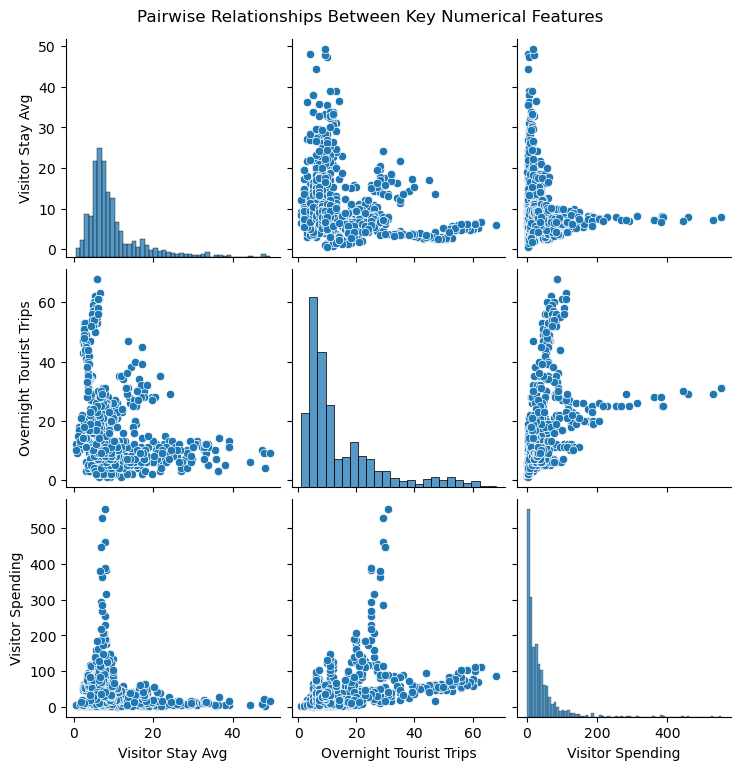

In [8]:
# 3. Pairplot: Key Numerical Relationships
sns.pairplot(df[['Visitor Stay Avg', 'Overnight Tourist Trips', 'Visitor Spending']])
plt.suptitle("Pairwise Relationships Between Key Numerical Features", y=1.02)
plt.show()

####  **Correlation Heatmap**  

A **correlation heatmap** is a **graphical representation** of the correlation between multiple variables in a dataset. It uses **colors** to indicate the strength and direction of relationships.  

  `**Key Points:**`  
✔ **Correlation values range from -1 to 1:**  
   - **+1** → Strong **positive** correlation (both increase together)  
   - **0** → No correlation (no relationship)  
   - **-1** → Strong **negative** correlation (one increases, the other decreases)  

✔ **Heatmaps use color gradients**:  
   - Darker colors indicate **stronger** correlations.  
   - Lighter colors indicate **weaker** or **no correlation**.  




Text(0.5, 1.0, 'Correlation Heatmap of Features')

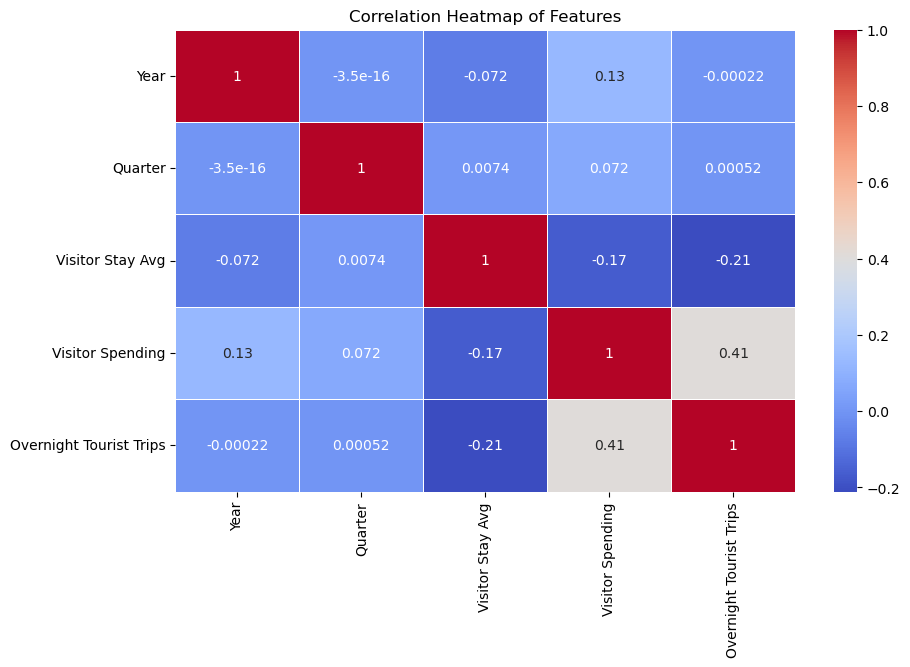

In [9]:
# 1. Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(exclude='object').corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Features")


#### **Insights from Pairplot and Correlation Heatmap**  

The analysis using the **Pairplot** and **Correlation Heatmap** reveals the following key findings about the dataset:  

---

#### 1. Data Skewness  
- The features **Visitor Stay Avg**, **Visitor Spending**, and **Overnight Tourist Trips** display a **right-skewed distribution**.  
- This means that most values are concentrated towards the lower end, with a longer tail extending to the right.  

#### 2. High Variability  
- The numerical features exhibit **considerable variance**, indicating a **wide spread of data points**.  
- Such dispersion suggests the potential need for normalization or scaling before further analysis.  

#### 3. Inter-feature Correlation  
- The correlation among features ranges from **low to moderate**.  
- No strong linear relationships were detected, implying that most variables are relatively independent.  


#### **Boxplot:** Visitor Spending by Reason for Journey  

The boxplot visualization helps analyze the distribution and outliers of numerical variables in the dataset. Each boxplot represents a numerical column, showing key statistical insights such as the median, quartiles, and potential outliers.  

##### Key Insights:  
- **Median & Quartiles**: The box highlights the interquartile range (IQR), with the median as a central line.  
- **Outliers**: Points outside the whiskers indicate extreme values that might require further analysis.  
- **Comparisons**: By examining multiple boxplots, we can compare distributions across different spending categories.  

This visualization is useful for identifying variations in visitor spending based on their journey reasons, helping in data-driven decision-making.

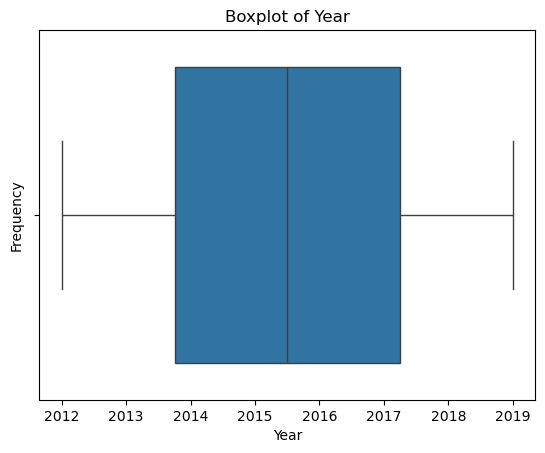

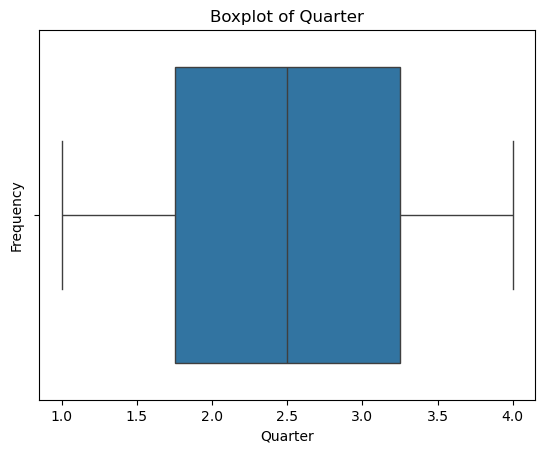

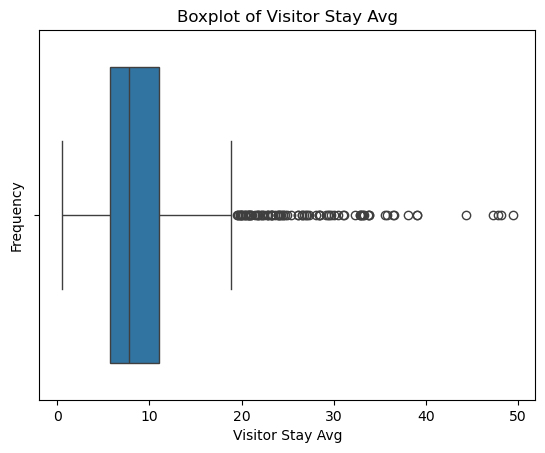

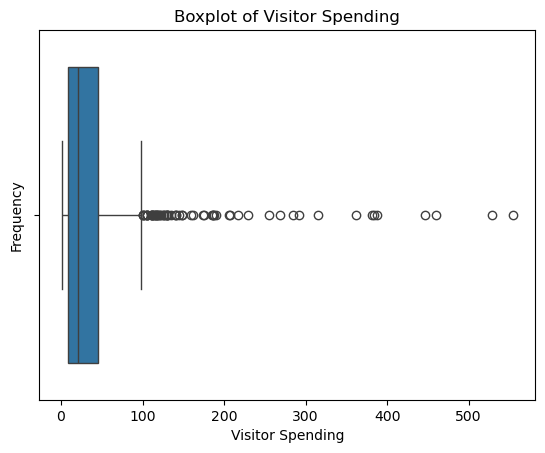

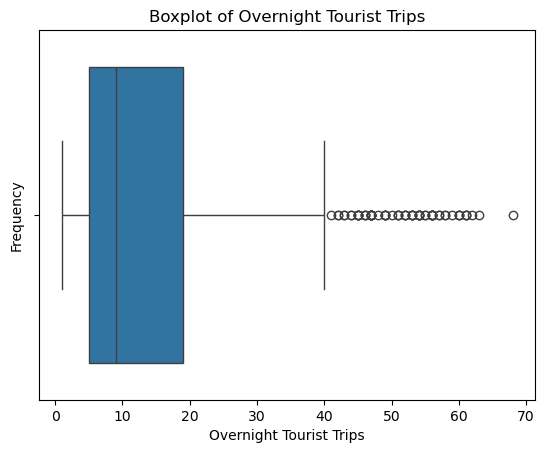

In [10]:
# 2. Boxplot: Visitor Spending by Reason for Journey
columns = df.select_dtypes(exclude=['object']).columns
for column in columns:
    sns.boxplot(data= df, x=column )
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

The boxplot illustrates the distribution of **Visitor Stay Avg**,**Visitor Spending**,**Overnight Tourist Trips**, showing key statistical insights:

#### Observations on Outliers:
- The `Visitor Stay Average` shows a significant number of outliers are present beyond the upper whisker, suggesting some visitors have exceptionally long stays.
- The `Visitor Spending` boxplot shows the numerous outliers(black circles) on the higher end, indicating that some visitors spend significantly more than the majority. These extreme values suggest a **right-skewed distribution**, where most data points are concentrated at lower spending levels.
- The `Overnight Tourist Trips` boxplot shows a cluster of outliers on the right side, extending from around 50 to 70 trips. These outliers indicate a small number of tourists taking significantly more overnight trips than the majority, which are concentrated between 0 and 30 trips.



#### **Which country spends the most in tourism**

#### Barplot of Visitor Spending by Year and Area of Residence

This barplot visualizes `visitor spending` across different years, with the data segmented by the visitors` area of residence`. Each bar represents the total spending for a specific year, and the bars are color-coded to distinguish between different areas of residence. The legend, titled `Area of Residence` is positioned just outside the plot's upper-right corner for clarity. In the context of the earlier boxplot of overnight tourist trips, this barplot could help identify trends in spending behavior across regions, potentially highlighting areas with unusually high spending that might correspond to the outliers observed in the number of overnight trips (e.g., those taking 50–70 trips).

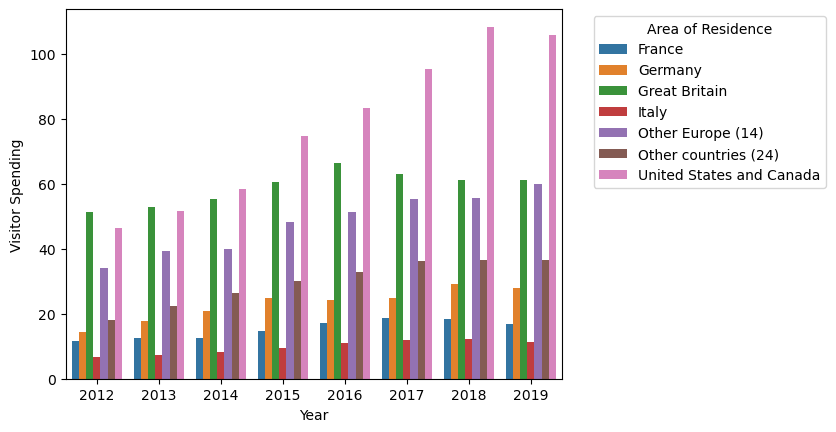

In [12]:
sns.barplot(data=df, x= 'Year', y= 'Visitor Spending', hue= 'Area of Residence', errorbar = None)
plt.legend(title = 'Area of Residence', bbox_to_anchor=(1.05, 1), loc= 'upper left')

The barplot shows `visitor spending` from 2012 to 2019, segmented by **area of residence**, with a notable peak in 2018 driven by high spending from the `United States` and `Canada`. Spending from `Great Britain` and Other `Europe` (14) consistently contributes the most across years, while `France`, `Germany`, and `Italy` show lower and more stable spending patterns.


### **Binomial Distribution**

The **Binomial Distribution** is a **discrete probability distribution** used to model the number of **successes** in a fixed number of independent trials, where **each trial has only two possible outcomes** — success or failure.


#### Probability Formula:


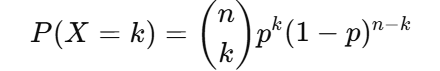


Where:
-  X  = number of successes
-  n  = total number of trials
-  k  = desired number of successes
-  p  = probability of success on each trial



### **`Visitor Spending`**

In a sample of 10 percent visitors from France traveling for Business, each has a 0.7 probability of spending more than 5 million Euros. What is the probability that exactly 7 percent of them spend more than 5 million Euros?

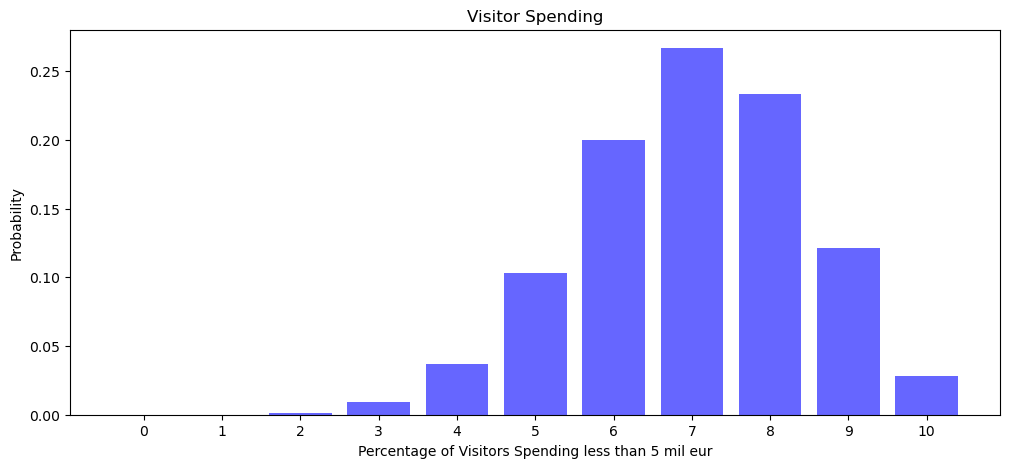

In [100]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.bar(np.arange(0, 11), binom.pmf(np.arange(0, 11), 10, 0.7), color='blue', alpha=0.6)
plt.xlabel('Percentage of Visitors Spending less than 5 mil eur')
plt.ylabel('Probability')
plt.title('Visitor Spending')
plt.xticks(np.arange(0, 11))
plt.show()

#### **Explanation of the Binomial Distribution Plot**  

This bar chart represents a **Binomial Distribution** for visitor spending, where each visitor has a **70% probability** of spending more than **5 million Euros**.  

#### Key Elements in the Chart:
1. **X-axis (Percentage of Visitors Spending Less Than €5M)**  
   - It ranges from **0 to 10**, representing the possible number of visitors (out of 10) who **do not** spend more than €5M.  
   - Since the probability of spending more than €5M is **0.7**, the probability of not spending more than €5M is **0.3**.
   
2. **Y-axis (Probability)**  
   - Represents the probability of each possible number of visitors **not** spending more than €5M.

3. **Shape of the Distribution**  
   - The highest bar is at **3 visitors**, meaning the most probable outcome is that **3 visitors (out of 10) do not spend more than €5M** (which also means that **7 visitors do spend more**).  
   - This matches the expected value:  
     \[
     E(X) = n \times p = 10 \times 0.3 = 3
     \]
   - The probability decreases as we move toward **0 or 10**, meaning it's **unlikely that all** or **none** of the visitors will avoid spending more than €5M.


### Interpretation:
- The **majority of the time**, around **6 to 8 visitors** will spend more than 5 units.
- It is **rare** (but not impossible) for very few (0-3) or all (9-10) visitors to spend more than 5 units.
- If we observe significantly fewer or more than 7 visitors spending more than 5 units, it might indicate a change in visitor behavior.




## **Poisson Distribution**  

The **Poisson Distribution** is a **discrete probability distribution** that models the number of times an event occurs in a fixed **time period** or **space**, given a known **average rate (λ)** and assuming events happen **independently**.  

#### Formula:

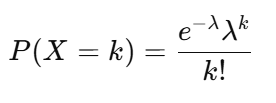

Where:  
-  X  = number of occurrences  
-  λ  = average rate of occurrence  
-  e  = Euler’s number (~2.718)  
-  k = factorial of \( k \)  


### **`Poisson Distribution`**

Suppose on average, 3 percent of visitors per quarter from the UK stay longer than 8 days. What is the probability that exactly 4 percent of such visitors are observed in a given quarter?

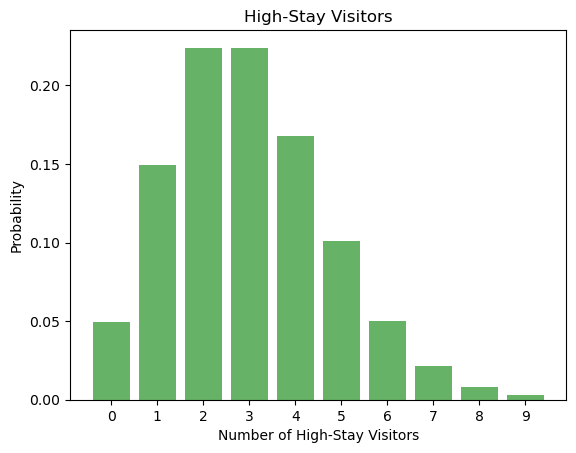

In [102]:
# Poisson Distribution Plot
plt.bar(np.arange(0, 10), poisson.pmf(np.arange(0, 10), 3), color='green', alpha=0.6)
plt.xlabel('Number of High-Stay Visitors')
plt.ylabel('Probability')
plt.title('High-Stay Visitors')
plt.xticks(np.arange(0, 10))
plt.show()

#### **Explanation of the Poisson Distribution Plot**  

This bar chart represents the **Poisson Distribution** of **high-stay visitors**, where the **average number of visitors staying longer than 8 days is 3 per quarter**. The graph shows the probability of observing **0 to 9** high-stay visitors in a given quarter.  


### Key Observations:
1. **X-axis (Number of High-Stay Visitors)**  
   - Represents the possible number of visitors who stay longer than 8 days in a quarter.  
   - It ranges from **0 to 9**, meaning we are considering cases where no visitors stay long, up to cases where 9 visitors stay longer than 8 days.

2. **Y-axis (Probability)**  
   - Represents the probability of each scenario occurring.  

3. **Peak at 2 and 3 Visitors**  
   - The **most likely number of high-stay visitors is 2 or 3**, as seen from the **tallest bars**.
   - This aligns with the **Poisson mean (λ = 3)**, which tells us the expected number of high-stay visitors per quarter.

4. **Right-Skewed Distribution**  
   - The probability **drops off quickly** after 5 or more visitors.  
   - This means it is **less likely to see a very high number of long-stay visitors** in a single quarter.

### Interpretation:
- In most quarters, we expect **around 3 high-stay visitors**.
- There is still a **meaningful probability** of observing **2 or 4 visitors**.
- Seeing **0 or 1 visitors** staying longer than 8 days is uncommon but possible.
- Observing **6 or more high-stay visitors would be quite unusual**, possibly indicating a special event or trend change.






#### **Final Takeaway**
- **The Binomial graph** suggests that in a group of 10 visitors, **expect around 7 to spend more than 5 units**, with very low chances of extreme cases.
- **The Poisson graph** suggests that in a quarter, **expect around 3 high-stay visitors**, but occasionally **as many as 5 or as few as 1**.



## **Outliers**

Using the Interquartile Range (IQR) method to identify and count outliers because the dataset is skewed and has outliers. The IQR method is robust for skewed data and provides a clear threshold for outlier detection

This Python code calculates and prints the number of outliers for specified columns ('Visitor Stay Avg', 'Visitor Spending', 'Overnight Tourist Trips') in a Pandas DataFrame (`df`). It uses the Interquartile Range (IQR) method:

1.  Calculates the 25th (`quartile1`) and 75th (`quartile3`) percentiles.
2.  Computes the IQR (`iqr`).
3.  Determines the minimum (`min_threshold`) and maximum (`max_threshold`) outlier thresholds.
4.  Identifies outliers as values outside these thresholds.
5.  Stores the count of outliers for each column in the `outlier_counts` dictionary, which is then printed.

Example output: `{'Visitor Stay Avg': 5, 'Visitor Spending': 10, 'Overnight Tourist Trips': 2}`.

In [49]:
columns = ['Visitor Stay Avg', 'Visitor Spending', 'Overnight Tourist Trips']
outlier_counts = {}
for column in columns:
        quartile1 = df[column].quantile(0.25)
        quartile3 = df[column].quantile(0.75)
        iqr = quartile3 - quartile1
        min_threshold = quartile1 - 1.5 * iqr
        max_threshold= quartile3 + 1.5 * iqr

        outliers = df[(df[column] < min_threshold) | (df[column] >  max_threshold)][column]
        outlier_counts[column] = len(outliers)
print(outlier_counts)

{'Visitor Stay Avg': 87, 'Visitor Spending': 65, 'Overnight Tourist Trips': 66}


#### Log Transforming the data

This Python code performs a log transformation on specified numerical columns within a Pandas DataFrame (`df`).

* It iterates through each column in the `columns` list.
* For each column, it applies the natural logarithm (`np.log()`) to the column's values.
* The resulting log-transformed values are stored in a new column within the DataFrame, with the name `original_column_name + '_log_Transform'`.

Essentially, it creates log-transformed versions of the original columns.

In [58]:
for column in columns:
    df[column + '_log_Transform'] = np.log(df[column])

`df.head()` displays the first few rows (typically 5) of the Pandas DataFrame `df`. This allows for a quick inspection of the data's structure and contents, showing the column names and sample values.

In [18]:
df.head()

,Year,Quarter,Area of Residence,Reason for Journey,Visitor Stay Avg,Visitor Spending,Overnight Tourist Trips,Visitor Stay Avg_log_Transform,Visitor Spending_log_Transform,Overnight Tourist Trips_log_Transform
0,2012,1,France,Business,6.6,9.0,9.0,1.887070,2.197225,2.197225
1,2012,2,France,Business,5.8,6.0,6.0,1.757858,1.791759,1.791759
2,2012,3,France,Business,9.3,6.0,7.0,2.230014,1.791759,1.945910
3,2012,4,France,Business,9.1,5.0,5.0,2.208274,1.609438,1.609438
4,2013,1,France,Business,6.0,7.0,8.0,1.791759,1.945910,2.079442


## Histograms of Log-Transformed Visitor Data  
This section displays histograms with kernel density estimation (KDE) for three log-transformed variables—`Visitor Stay Avg`, `Visitor Spending`, and `Overnight Tourist Trips`—using 25 bins each, with titles and labels reflecting the respective column names.

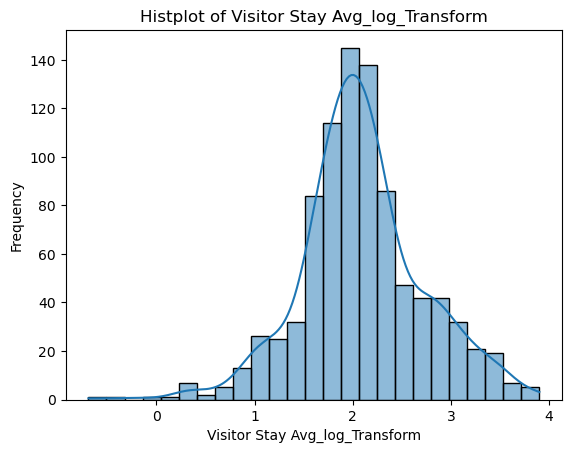

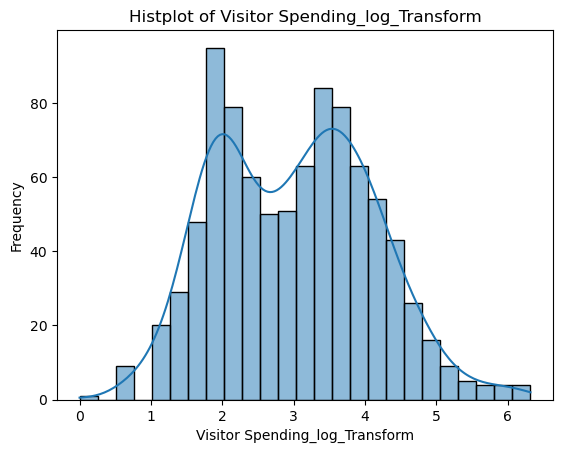

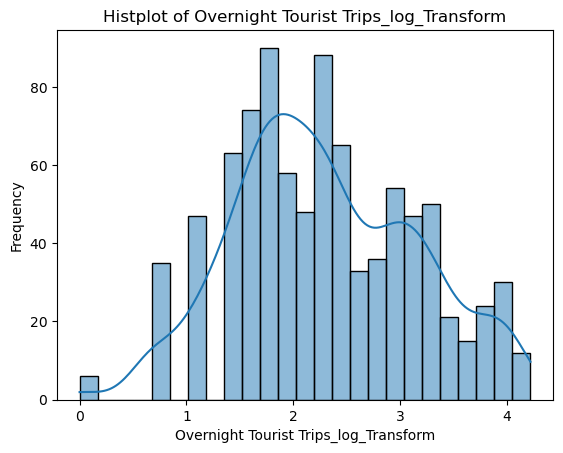

In [19]:
columns = ['Visitor Stay Avg_log_Transform', 'Visitor Spending_log_Transform', 'Overnight Tourist Trips_log_Transform']
for column in columns:
    sns.histplot(data=df, x= column, kde=True, bins=25)
    plt.title(f"Histplot of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

`->`The histogram displays the distribution of the log-transformed average visitor stay (**Visitor Stay Avg_log_Transform**) with 25 bins and a kernel       density estimation (KDE) curve overlaid. The data is right-skewed, with a peak around 2.5, indicating that most visitors have a log-transformed stay     average between 2 and 3, while a smaller number have shorter stays (near 0) or longer stays (up to 4).

`->`The histogram shows the distribution of log-transformed visitor spending (**Visitor Spending_log_Transform**) with 25 bins and a kernel density          estimation (KDE) curve. It exhibits a bimodal distribution with peaks around 2.5 and 4, suggesting two distinct groups of visitors: one with             moderate spending (around 2–3) and another with higher spending (around 4), with fewer visitors spending at the extremes (near 0 or 6).

`->`The histogram of log-transformed overnight tourist trips (**Overnight Tourist Trips_log_Transform**) with 25 bins and a KDE curve shows a bimodal        distribution with peaks around 1.5 and 3. This suggests two groups of tourists: one taking fewer trips (around 1–2 log units) and another taking         more(around 3), with a smaller number of extreme values near 0 and 4.

#### **Boxplots of Log-Transformed Visitor Data**  
This section presents boxplots for three log-transformed variables—`Visitor Stay Avg`, `Visitor Spending`, and `Overnight Tourist Trips`—each showing the distribution, median, quartiles, and potential outliers, with titles and labels reflecting the respective column names.

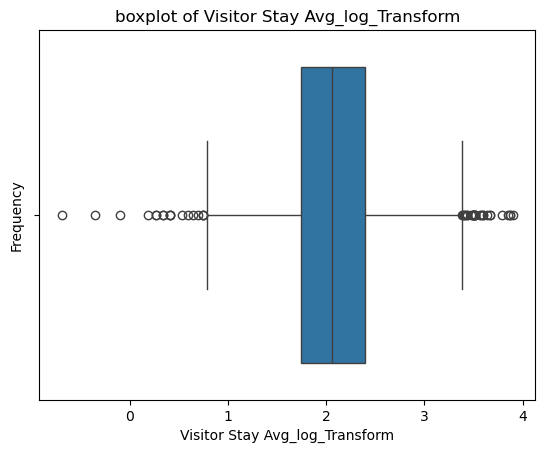

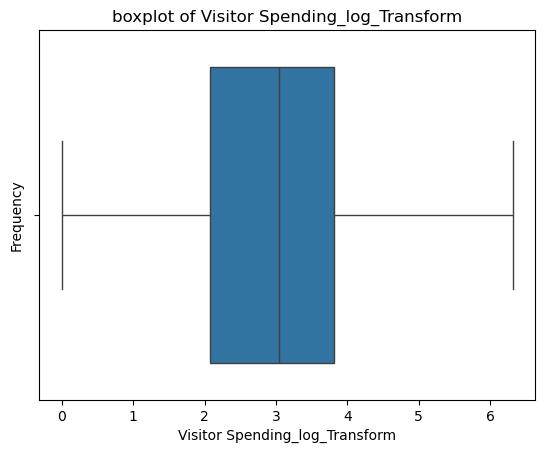

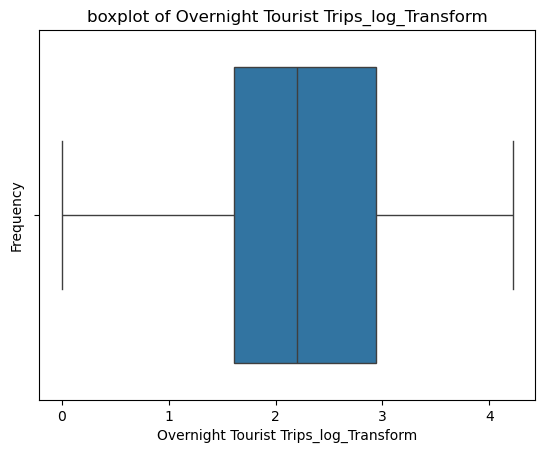

In [20]:
columns = ['Visitor Stay Avg_log_Transform', 'Visitor Spending_log_Transform', 'Overnight Tourist Trips_log_Transform']
for column in columns:
    sns.boxplot(data=df, x= column)
    plt.title(f"boxplot of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

`->`The boxplot of log-transformed **Visitor Stay Avg** (Visitor Stay Avg_log_Transform) shows a median around 2.5, with the interquartile range (IQR)       spanning roughly 2 to 3, indicating most visitors' stay averages fall in this range. Outliers are present on both ends, with a few visitors having       very short stays (near 0) and others with longer stays (around 4), suggesting variability in stay duration.

`->`This boxplot shows the log-transformed **visitor spending** distribution, with most values (IQR) between 1 and 3 and a median around 2. No outliers      are present, indicating the log transformation normalized the data, aligning with the moderate spending trends seen in the earlier barplot.

`->`This boxplot displays the log-transformed distribution of **overnight tourist trips**, with most values (IQR) between 1 and 2.5 and a median around      1.5.No outliers are visible, suggesting the log transformation normalized the data, contrasting with the earlier boxplot of raw trips that showed        outliers between 50 and 70.